# Artificial Neural Network




In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Importing the libraries

In [3]:
import pandas as pd
import numpy as np
import torch
import sys


In [40]:
torch.__version__

'2.10.0+cpu'

## Part 1 - Data Preprocessing

### Importing the dataset

In [26]:
stroke_train=pd.read_csv('/content/drive/MyDrive/datafiles/heartstroke/train.csv')
stroke_test=pd.read_csv('/content/drive/MyDrive/datafiles/heartstroke/test.csv')
X=stroke_train.iloc[:,1:-1].values
y=stroke_train.iloc[:,-1].values
X_test_eval=stroke_test.iloc[:,1:].values

stroke_train

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,Male,28.0,0,0,Yes,Private,Urban,79.53,31.1,never smoked,0
1,1,Male,33.0,0,0,Yes,Private,Rural,78.44,23.9,formerly smoked,0
2,2,Female,42.0,0,0,Yes,Private,Rural,103.00,40.3,Unknown,0
3,3,Male,56.0,0,0,Yes,Private,Urban,64.87,28.8,never smoked,0
4,4,Female,24.0,0,0,No,Private,Rural,73.36,28.8,never smoked,0
...,...,...,...,...,...,...,...,...,...,...,...,...
15299,15299,Female,22.0,0,0,No,Govt_job,Urban,72.63,19.5,never smoked,0
15300,15300,Female,46.0,1,0,Yes,Private,Urban,101.19,32.1,never smoked,0
15301,15301,Female,75.0,0,0,Yes,Self-employed,Urban,87.69,26.2,never smoked,0
15302,15302,Male,46.0,0,0,Yes,Private,Rural,101.13,22.5,Unknown,0


In [27]:
stroke_test

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,15304,Female,57.0,0,0,Yes,Private,Rural,82.54,33.4,Unknown
1,15305,Male,70.0,1,0,Yes,Private,Urban,72.06,28.5,Unknown
2,15306,Female,5.0,0,0,No,children,Urban,103.72,19.5,Unknown
3,15307,Female,56.0,0,0,Yes,Govt_job,Urban,69.24,41.4,smokes
4,15308,Male,32.0,0,0,Yes,Private,Rural,111.15,30.1,smokes
...,...,...,...,...,...,...,...,...,...,...,...
10199,25503,Female,27.0,0,0,No,Private,Urban,75.77,17.6,never smoked
10200,25504,Male,49.0,0,0,Yes,Private,Urban,102.91,26.7,Unknown
10201,25505,Female,3.0,0,0,No,children,Rural,104.04,18.3,Unknown
10202,25506,Male,31.0,0,0,Yes,Private,Urban,82.41,28.7,never smoked


In [28]:
# Disable truncation
with np.printoptions(threshold=sys.maxsize):
    print(X)

[['Male' 28.0 0 0 'Yes' 'Private' 'Urban' 79.53 31.1 'never smoked']
 ['Male' 33.0 0 0 'Yes' 'Private' 'Rural' 78.44 23.9 'formerly smoked']
 ['Female' 42.0 0 0 'Yes' 'Private' 'Rural' 103.0 40.3 'Unknown']
 ['Male' 56.0 0 0 'Yes' 'Private' 'Urban' 64.87 28.8 'never smoked']
 ['Female' 24.0 0 0 'No' 'Private' 'Rural' 73.36 28.8 'never smoked']
 ['Female' 34.0 0 0 'Yes' 'Private' 'Urban' 84.35 22.2 'Unknown']
 ['Female' 53.0 0 0 'Yes' 'Private' 'Rural' 88.97 25.3 'never smoked']
 ['Male' 78.0 0 1 'Yes' 'Self-employed' 'Rural' 75.32 24.8 'Unknown']
 ['Female' 45.0 0 0 'Yes' 'Private' 'Rural' 107.22 34.1 'never smoked']
 ['Female' 62.0 0 0 'Yes' 'Govt_job' 'Urban' 62.68 18.4 'formerly smoked']
 ['Male' 51.0 0 0 'Yes' 'Self-employed' 'Urban' 114.89 20.1
  'never smoked']
 ['Female' 45.0 0 0 'Yes' 'Private' 'Urban' 69.94 23.5 'never smoked']
 ['Female' 4.0 0 0 'No' 'children' 'Urban' 84.1 14.1 'Unknown']
 ['Male' 23.0 0 0 'No' 'Private' 'Urban' 112.09 37.3 'smokes']
 ['Female' 36.0 0 0 'Yes

In [29]:
y

array([0, 0, 0, ..., 0, 0, 0])

In [14]:
X_test_eval

array([['Female', 57.0, 0, ..., 82.54, 33.4, 'Unknown'],
       ['Male', 70.0, 1, ..., 72.06, 28.5, 'Unknown'],
       ['Female', 5.0, 0, ..., 103.72, 19.5, 'Unknown'],
       ...,
       ['Female', 3.0, 0, ..., 104.04, 18.3, 'Unknown'],
       ['Male', 31.0, 0, ..., 82.41, 28.7, 'never smoked'],
       ['Female', 2.0, 0, ..., 85.12, 14.8, 'Unknown']], dtype=object)

### Encoding categorical data

*Label* Encoding the "Gender" column

In [30]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Label encoding gender column
X[:,0] = le.fit_transform(X[:,0])
#Label encoding ever_married
X[:,4] = le.fit_transform(X[:,4])


#Label encoding test data set for gender and ever_married
# Label encoding gender column
X_test_eval[:,0] = le.fit_transform(X_test[:,0])
#Label encoding ever_married
X_test_eval[:,4] = le.fit_transform(X_test[:,4])

In [31]:
print('First 5 rows of X:\n', X[:10])

First 5 rows of X:
 [[1 28.0 0 0 1 'Private' 'Urban' 79.53 31.1 'never smoked']
 [1 33.0 0 0 1 'Private' 'Rural' 78.44 23.9 'formerly smoked']
 [0 42.0 0 0 1 'Private' 'Rural' 103.0 40.3 'Unknown']
 [1 56.0 0 0 1 'Private' 'Urban' 64.87 28.8 'never smoked']
 [0 24.0 0 0 0 'Private' 'Rural' 73.36 28.8 'never smoked']
 [0 34.0 0 0 1 'Private' 'Urban' 84.35 22.2 'Unknown']
 [0 53.0 0 0 1 'Private' 'Rural' 88.97 25.3 'never smoked']
 [1 78.0 0 1 1 'Self-employed' 'Rural' 75.32 24.8 'Unknown']
 [0 45.0 0 0 1 'Private' 'Rural' 107.22 34.1 'never smoked']
 [0 62.0 0 0 1 'Govt_job' 'Urban' 62.68 18.4 'formerly smoked']]


In [32]:
print('First 5 rows of X:\n', X_test_eval[:5])

First 5 rows of X:
 [[0 57.0 0 0 1 'Private' 'Rural' 82.54 33.4 'Unknown']
 [1 70.0 1 0 1 'Private' 'Urban' 72.06 28.5 'Unknown']
 [0 5.0 0 0 0 'children' 'Urban' 103.72 19.5 'Unknown']
 [0 56.0 0 0 1 'Govt_job' 'Urban' 69.24 41.4 'smokes']
 [1 32.0 0 0 1 'Private' 'Rural' 111.15 30.1 'smokes']]


One Hot Encoding the "work_type","residence_type" column





In [33]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ct=ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[5,6,9])],remainder='passthrough')
X=ct.fit_transform(X)
X_test_eval=ct.fit_transform(X_test_eval)
#

In [34]:
print('Shape of X:', X.shape)

Shape of X: (15304, 18)


In [35]:
print('First 5 rows of X:\n', X[:5])

First 5 rows of X:
 [[0.0 0.0 1.0 0.0 0.0 0.0 1.0 0.0 0.0 1.0 0.0 1 28.0 0 0 1 79.53 31.1]
 [0.0 0.0 1.0 0.0 0.0 1.0 0.0 0.0 1.0 0.0 0.0 1 33.0 0 0 1 78.44 23.9]
 [0.0 0.0 1.0 0.0 0.0 1.0 0.0 1.0 0.0 0.0 0.0 0 42.0 0 0 1 103.0 40.3]
 [0.0 0.0 1.0 0.0 0.0 0.0 1.0 0.0 0.0 1.0 0.0 1 56.0 0 0 1 64.87 28.8]
 [0.0 0.0 1.0 0.0 0.0 1.0 0.0 0.0 0.0 1.0 0.0 0 24.0 0 0 0 73.36 28.8]]


In [36]:
print('First 5 rows of X:\n', X_test_eval[:5])

First 5 rows of X:
 [[0.0 0.0 1.0 0.0 0.0 1.0 0.0 1.0 0.0 0.0 0.0 0 57.0 0 0 1 82.54 33.4]
 [0.0 0.0 1.0 0.0 0.0 0.0 1.0 1.0 0.0 0.0 0.0 1 70.0 1 0 1 72.06 28.5]
 [0.0 0.0 0.0 0.0 1.0 0.0 1.0 1.0 0.0 0.0 0.0 0 5.0 0 0 0 103.72 19.5]
 [1.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 1.0 0 56.0 0 0 1 69.24 41.4]
 [0.0 0.0 1.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 1.0 1 32.0 0 0 1 111.15 30.1]]


### Splitting the dataset into the Training set and Test set

In [21]:
# NumPy defaults to the object dtype if your original Pandas DataFrame contains mixed data types, hidden strings, or NaN (missing) values

print(X_train.dtype)

object


PyTorch needs to know exactly how many bits each number takes up to move data to the GPU. An object array is just a collection of pointers to Python objects scattered in memory, whereas float32 is a dense block of 32-bit numbers that PyTorch can process efficiently.

In [37]:
# PyTorch's from_numpy() or torch.tensor() cannot convert object arrays
# because they require a contiguous block of numeric memory.

# Convert to float32 (the standard for PyTorch weights)
X = X.astype(np.float32)
y = y.astype(np.float32)
X_test_eval=X_test_eval.astype(np.float32)

print(X.dtype)
print(y.dtype)
print(X_test_eval.dtype)


float32
float32
float32


In [38]:
print('First 5 rows of X:\n', X[:2,:])

First 5 rows of X:
 [[ 0.    0.    1.    0.    0.    0.    1.    0.    0.    1.    0.    1.
  28.    0.    0.    1.   79.53 31.1 ]
 [ 0.    0.    1.    0.    0.    1.    0.    0.    1.    0.    0.    1.
  33.    0.    0.    1.   78.44 23.9 ]]


In [39]:
# Turn data into tensors
# Otherwise this causes issues with computations later on
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X_test_eval=torch.from_numpy(X_test_eval).type(torch.float)

# View the first five samples
X[:5], y[:5],X_test_eval[:5]

(tensor([[  0.0000,   0.0000,   1.0000,   0.0000,   0.0000,   0.0000,   1.0000,
            0.0000,   0.0000,   1.0000,   0.0000,   1.0000,  28.0000,   0.0000,
            0.0000,   1.0000,  79.5300,  31.1000],
         [  0.0000,   0.0000,   1.0000,   0.0000,   0.0000,   1.0000,   0.0000,
            0.0000,   1.0000,   0.0000,   0.0000,   1.0000,  33.0000,   0.0000,
            0.0000,   1.0000,  78.4400,  23.9000],
         [  0.0000,   0.0000,   1.0000,   0.0000,   0.0000,   1.0000,   0.0000,
            1.0000,   0.0000,   0.0000,   0.0000,   0.0000,  42.0000,   0.0000,
            0.0000,   1.0000, 103.0000,  40.3000],
         [  0.0000,   0.0000,   1.0000,   0.0000,   0.0000,   0.0000,   1.0000,
            0.0000,   0.0000,   1.0000,   0.0000,   1.0000,  56.0000,   0.0000,
            0.0000,   1.0000,  64.8700,  28.8000],
         [  0.0000,   0.0000,   1.0000,   0.0000,   0.0000,   1.0000,   0.0000,
            0.0000,   0.0000,   1.0000,   0.0000,   0.0000,  24.0000,   0.00

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

### Feature Scaling

In [41]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
X_test_eval=sc.transform(X_test_eval)

In [42]:
print('First 5 rows of X:\n', X_train[:2,:])

First 5 rows of X:
 [[-0.33222805 -0.05198752  0.75432879 -0.38199363 -0.39203818  0.99340572
  -0.99340572  1.53435543 -0.42391871 -0.83057515 -0.4056577  -0.79127274
   1.70933474 -0.2303708  -0.15685844  0.69169692  5.0604694  -0.18141361]
 [-0.33222805 -0.05198752  0.75432879 -0.38199363 -0.39203818 -1.00663806
   1.00663806 -0.65173947  2.35894283 -0.83057515 -0.4056577   1.26291559
   0.21701302 -0.2303708  -0.15685844  0.69169692 -0.77829492  0.05569689]]


Check the Shapes

In [43]:
X_train.shape,y_train.shape

((12243, 18), torch.Size([12243]))

## Part 2 - Building the ANN

### Initializing the ANN

In [44]:
# Standard PyTorch imports
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [45]:
class ANN_binaryClassifier(nn.Module):# Any argument defined at the class level is used by Python for inheritance

  def __init__(self,input_dim):
    super(ANN_binaryClassifier, self).__init__()

    # defining forward neural network
    self.layer1=nn.Linear(input_dim,9)
    self.layer2=nn.Linear(9,4)
    self.output = nn.Linear(4, 1) # Output layer
    self.relu = nn.ReLU()

  def forward(self, x):
    out = self.relu(self.layer1(x))
    out = self.relu(self.layer2(out))
    out = self.output(out)
    return out


# Forward pass calling class ANN_binaryClassifier
model = ANN_binaryClassifier(X_train.shape[1]).to(device)



### Preparing data for training





In [46]:
from torch.utils.data import DataLoader, TensorDataset



# Step A: Ensure data is in Float32 Tensors (Standard for PyTorch)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

# Put data to target device
X_train_tensor, y_train_tensor = X_train_tensor.to(device), y_train_tensor.to(device)

# Step B: Combine X and y into one Dataset object
# This keeps your features and labels "glued" together during shuffling
train_data = TensorDataset(X_train_tensor, y_train_tensor)

# Step C: Create the DataLoader
# batch_size=32 is a standard starting point for most ANNs
train_loader = DataLoader(dataset=train_data, batch_size=32, shuffle=True)


/tmp/ipykernel_699/1615863743.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train, dtype=torch.float32)


## Part 3 - Training the ANN

### Training the ANN on the Training set

In [52]:
import torch

# 1. Setup Loss and Optimizer
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

def train_model(model, train_loader, epochs=100):
    train_losses = []
    train_accuracies = []
    for epoch in range(epochs):
        model.train() # Set to training mode

        train_loss, train_acc = 0, 0

        for X_batch, y_batch in train_loader:
            # Squeeze to ensure shapes are 1D: [batch_size]
            y_logits = model(X_batch).squeeze()
            y_batch = y_batch.squeeze()

            #1. Calculate the loss
            # The model's outputs (predictions/logits) are compared to the
            # ground truth and evaluated to see how wrong they are.
            loss = loss_fn(y_logits, y_batch)

            # 2. Accuracy Calculation (Manual)
            # Step A: Convert logits -> probabilities (0 to 1)
            y_probs = torch.sigmoid(y_logits)
            # Step B: Round probabilities -> classes (0 or 1)
            y_preds = torch.round(y_probs)
            # Step C: Compare accuracy
            acc = (y_preds == y_batch).sum().item() / len(y_batch)

            # 3. Optimization steps

            # Zero gradients
            # The optimizers gradients are set to zero (they are accumulated by default)
            # so they can be recalculated for the specific training step.
            optimizer.zero_grad()

             # Backpropagation
             # Computes the gradient of the loss with respect for every model parameter
             # to be updated. This is known as backpropagation.
            loss.backward()


            # Update weights
            # Update the parameters with requires_grad=True with respect to the
            # loss gradients in order to improve them.
            optimizer.step()

            train_loss += loss.item()
            train_acc += acc

        # Calculate average train loss and accuracy
        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = (train_acc / len(train_loader)) * 100

        train_losses.append(avg_train_loss)
        train_accuracies.append(avg_train_acc)

        # Print results every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3} | Train Loss: {avg_train_loss:.4f} | Train Accuracy: {avg_train_acc:.2f}%")
    return train_losses, train_accuracies

# Run the training
train_losses, train_accuracies = train_model(model, train_loader)

Epoch  10 | Train Loss: 0.1201 | Train Accuracy: 95.87%
Epoch  20 | Train Loss: 0.1201 | Train Accuracy: 95.91%
Epoch  30 | Train Loss: 0.1193 | Train Accuracy: 95.92%
Epoch  40 | Train Loss: 0.1197 | Train Accuracy: 95.95%
Epoch  50 | Train Loss: 0.1198 | Train Accuracy: 95.93%
Epoch  60 | Train Loss: 0.1195 | Train Accuracy: 95.94%
Epoch  70 | Train Loss: 0.1190 | Train Accuracy: 95.88%
Epoch  80 | Train Loss: 0.1193 | Train Accuracy: 95.90%
Epoch  90 | Train Loss: 0.1192 | Train Accuracy: 95.91%
Epoch 100 | Train Loss: 0.1191 | Train Accuracy: 95.88%


## Part 4 - Making the predictions and evaluating the model

### Evaluation on test data set

In [48]:
def evaluate_model(model, test_loader):
    model.eval() # Set to evaluation mode
    test_loss, test_acc = 0, 0
    with torch.inference_mode(): # Turn off gradient tracking for evaluation
        for X_test_batch, y_test_batch in test_loader:
            y_test_logits = model(X_test_batch).squeeze()
            y_test_batch = y_test_batch.squeeze()

            loss = loss_fn(y_test_logits, y_test_batch)
            y_test_probs = torch.sigmoid(y_test_logits)
            y_test_preds = torch.round(y_test_probs)
            acc = (y_test_preds == y_test_batch).sum().item() / len(y_test_batch)

            test_loss += loss.item()
            test_acc += acc

    # Calculate average test loss and accuracy
    avg_test_loss = test_loss / len(test_loader)
    avg_test_acc = (test_acc / len(test_loader)) * 100
    print(f"\nTest Loss: {avg_test_loss:.4f} | Test Accuracy: {avg_test_acc:.2f}%")

# Call the evaluate_model function after training

# Define test_loader
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

X_test_tensor, y_test_tensor = X_test_tensor.to(device), y_test_tensor.to(device)

test_data = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(dataset=test_data, batch_size=32, shuffle=False)

evaluate_model(model, test_loader)


Test Loss: 0.1322 | Test Accuracy: 96.01%


/tmp/ipykernel_699/1947384657.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


### Predicting the result of a single observation

**Homework**

Use our ANN model to predict if the customer with the following informations will leave the bank:

Geography: France

Credit Score: 600

Gender: Male

Age: 40 years old

Tenure: 3 years

Balance: \$ 60000

Number of Products: 2

Does this customer have a credit card? Yes

Is this customer an Active Member: Yes

Estimated Salary: \$ 50000

So, should we say goodbye to that customer?

**Solution**

In [ ]:
new_customer = np.array([[1.0, 0.0, 0.0, 600, 1, 40, 3, 60000, 2, 1, 1, 50000]], dtype=np.float32)

# Scale the new customer data using the fitted StandardScaler
new_customer_scaled = sc.transform(new_customer)

# Convert to PyTorch tensor
new_customer_tensor = torch.tensor(new_customer_scaled, dtype=torch.float32).to(device)

# Make prediction
model.eval()
with torch.inference_mode():
    # Get logits
    prediction_logits = model(new_customer_tensor)
    # Apply sigmoid to get probability
    prediction_prob = torch.sigmoid(prediction_logits)
    # Round to get binary prediction
    prediction = torch.round(prediction_prob)

if prediction.item() == 1:
    print("This customer is predicted to leave the bank.")
else:
    print("This customer is predicted to stay in the bank.")

This customer is predicted to stay in the bank.


Therefore, our ANN model predicts that this customer stays in the bank!

**Important note 1:** Notice that the values of the features were all input in a double pair of square brackets. That's because the "predict" method always expects a 2D array as the format of its inputs. And putting our values into a double pair of square brackets makes the input exactly a 2D array.

**Important note 2:** Notice also that the "France" country was not input as a string in the last column but as "1, 0, 0" in the first three columns. That's because of course the predict method expects the one-hot-encoded values of the state, and as we see in the first row of the matrix of features X, "France" was encoded as "1, 0, 0". And be careful to include these values in the first three columns, because the dummy variables are always created in the first columns.

### Predicting the Test set results

In [50]:
model.eval() # Set the model to evaluation mode

with torch.inference_mode(): # Disable gradient calculations
    y_logits_test = model(X_test_tensor).squeeze() # Make predictions and squeeze the output
    y_pred_probs = torch.sigmoid(y_logits_test) # Apply sigmoid to get probabilities
    y_pred = torch.round(y_pred_probs) # Round to get binary predictions (0 or 1)

y_pred_numpy = y_pred.cpu().numpy() # Convert to numpy array for concatenation
y_test_numpy = y_test_tensor.cpu().numpy() # Convert y_test to numpy array

with np.printoptions(threshold=sys.maxsize):
  print(np.concatenate((y_pred_numpy.reshape(len(y_pred_numpy), 1), y_test_numpy.reshape(len(y_test_numpy), 1)), 1))



[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 1.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 1.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 1.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 

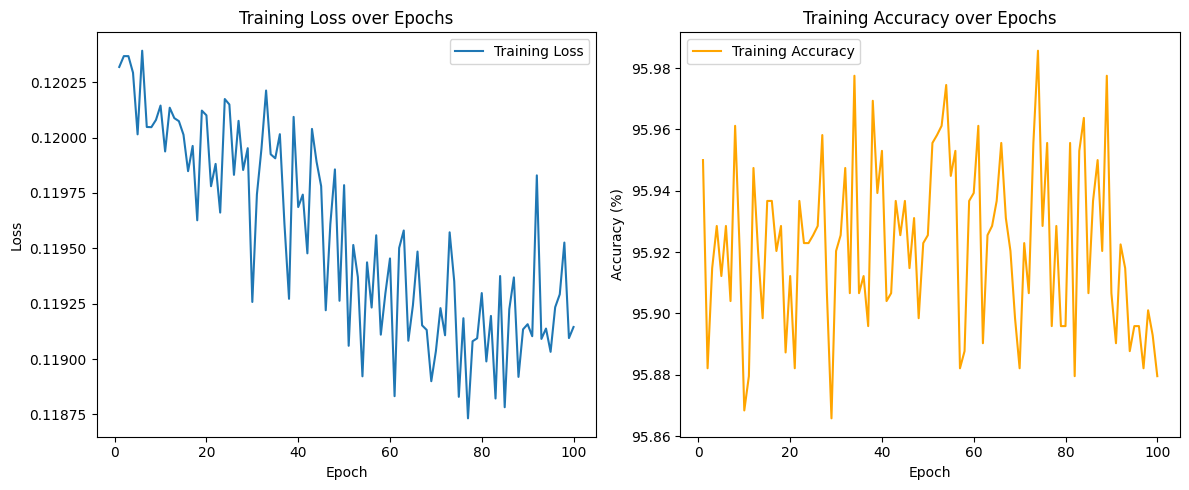

In [53]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Training Accuracy', color='orange')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

### Making the Confusion Matrix

In [51]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test_numpy, y_pred_numpy)
print(cm)
accuracy_score(y_test_numpy, y_pred_numpy)

[[2936    5]
 [ 117    3]]


0.9601437438745508